# Training

 Install packages

In [24]:
!uv pip install -q boto3==1.42.68 catboost==1.2.10 imbalanced-learn==0.14.1 lightgbm==4.6.0 matplotlib==3.10.8 mlflow==3.10.1 mlflow-skinny==3.10.1 mlflow-tracing==3.10.1 numpy==2.4.3 pandas==2.3.3 pyarrow==23.0.1 scikit-learn==1.8.0 seaborn==0.13.2 shap==0.51.0 xgboost==3.2.0 optuna==4.7.0 optuna-integration==4.7.0

In [25]:
!uv pip freeze | grep -E "scikit-learn|xgboost|lightgbm|catboost|mlflow|boto3|pyarrow|pandas|numpy|matplotlib|seaborn|shap|imbalanced-learn|optuna|optuna-integration"

boto3==1.42.68
catboost==1.2.10
imbalanced-learn==0.14.1
lightgbm==4.6.0
matplotlib==3.10.8
mlflow==3.10.1
mlflow-skinny==3.10.1
mlflow-tracing==3.10.1
numpy==2.4.3
optuna==4.7.0
optuna-integration==4.7.0
pandas==2.3.3
pyarrow==23.0.1
scikit-learn==1.8.0
seaborn==0.13.2
shap==0.51.0
xgboost==3.2.0


Import packages

In [31]:
import io
import pickle
import warnings
from typing import Any, Dict, Tuple, Union

import boto3
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
import shap
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from optuna.samplers import TPESampler
from optuna.trial import Trial
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier

In [27]:
warnings.filterwarnings("ignore")

S3_ENDPOINT = "http://localstack:4566"
BUCKET = "data-lake"
PREFIX = "gold/credit_risk/features/ingestion_date=2026-03-14/"
TARGET = "serious_dlqin2yrs"
RANDOM_STATE: int = 42

MLFLOW_TRACKING_URI = "http://mlflow:5000"
EXPERIMENT_NAME = "credit_risk_training"

s3_client = boto3.client("s3")

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name(EXPERIMENT_NAME)

optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"Experiment: {exp.name} (id={exp.experiment_id})")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Artifact store: {exp.artifact_location}")

Experiment: credit_risk_training (id=1)
Tracking URI: http://mlflow:5000
Artifact store: mlflow-artifacts:/1


## Evaluation Helper Functions

In [5]:
def ks_statistic(
    y_true: Union[np.ndarray, pd.Series], y_prob: Union[np.ndarray, pd.Series]
) -> float:
    false_positive_rate, true_positive_rate, _ = roc_curve(y_true, y_prob)
    return float(np.max(true_positive_rate - false_positive_rate))


def gini(auc: float) -> float:
    return 2.0 * auc - 1.0


def evaluate(
    model: BaseEstimator,
    X: Union[np.ndarray, pd.DataFrame],
    y: Union[np.ndarray, pd.Series],
    split_name: str,
    log_to_mlflow: bool = True,
) -> Dict[str, float]:

    # Get probabilities for the positive class
    y_prob: np.ndarray = model.predict_proba(X)[:, 1]

    auc: float = float(roc_auc_score(y, y_prob))
    ks: float = ks_statistic(y, y_prob)
    pr_auc: float = float(average_precision_score(y, y_prob))
    g: float = gini(auc)

    metrics: Dict[str, float] = {
        f"{split_name}_auc_roc": round(auc, 4),
        f"{split_name}_ks": round(ks, 4),
        f"{split_name}_gini": round(g, 4),
        f"{split_name}_pr_auc": round(pr_auc, 4),
    }

    if log_to_mlflow:
        mlflow.log_metrics(metrics)

    print(
        f"  [{split_name}] AUC={auc:.4f} | KS={ks:.4f} | Gini={g:.4f} | PR-AUC={pr_auc:.4f}"
    )

    return metrics


def cv_score(
    model: BaseEstimator,
    X: Union[np.ndarray, pd.DataFrame],
    y: Union[np.ndarray, pd.Series],
    n_splits: int = 5,
) -> Tuple[float, float]:

    cv: StratifiedKFold = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    # cross_val_score returns a numpy array of scores for each fold
    scores: np.ndarray = cross_val_score(
        model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1
    )

    mean_score: float = float(scores.mean())
    std_score: float = float(scores.std())

    print(f"  [CV-{n_splits}fold] AUC={mean_score:.4f} ± {std_score:.4f}")

    return mean_score, std_score

## Load Gold from S3

In [6]:
keys = [
    o["Key"]
    for o in s3_client.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX).get("Contents", [])
    if o["Key"].endswith(".parquet")
]

df = pd.concat(
    [
        pd.read_parquet(
            io.BytesIO(s3_client.get_object(Bucket=BUCKET, Key=k)["Body"].read())
        )
        for k in keys
    ],
    ignore_index=True,
)

# drop partition column written by Spark — not a feature
df = df.drop(columns=["ingestion_date"], errors="ignore")

df.head()

,serious_dlqin2yrs,revolving_utilization_of_unsecured_lines,age,number_of_time30_59_days_past_due_not_worse,debt_ratio,monthly_income,number_of_open_credit_lines_and_loans,number_of_times90_days_late,number_real_estate_loans_or_lines,number_of_time60_89_days_past_due_not_worse,number_of_dependents,monthly_income_is_missing,number_of_dependents_is_missing,delinquency_score,debt_to_income_ratio,unsecured_to_total_lines_ratio,age_risk_bucket,has_any_delinquency
0,0,1.000000,49,0,2883.000000,0.0,9,0,2,0,1.0,0,0,0.0,NaN,0.777778,middle,0
1,1,1.000000,44,2,0.547762,6500.0,13,0,4,0,2.0,0,0,2.0,0.000084,0.692308,middle,1
2,0,0.001102,58,0,0.396173,3500.0,6,0,2,0,0.0,0,0,0.0,0.000113,0.666667,senior,0
3,0,0.018978,61,0,1129.000000,NaN,9,0,1,0,0.0,1,0,0.0,NaN,0.888889,senior,0
4,0,0.047006,40,0,0.183151,5388.0,12,0,0,0,0.0,0,0,0.0,0.000034,1.000000,middle,0


In [7]:
print(f"Shape: {df.shape}\n")
print(f"Columns: {df.columns.tolist()}\n")
print(f"\nTarget distribution:\n{df[TARGET].value_counts()}\n")
print(f"Default rate: {df[TARGET].mean()*100:.2f}%\n")

Shape: (149390, 18)

Columns: ['serious_dlqin2yrs', 'revolving_utilization_of_unsecured_lines', 'age', 'number_of_time30_59_days_past_due_not_worse', 'debt_ratio', 'monthly_income', 'number_of_open_credit_lines_and_loans', 'number_of_times90_days_late', 'number_real_estate_loans_or_lines', 'number_of_time60_89_days_past_due_not_worse', 'number_of_dependents', 'monthly_income_is_missing', 'number_of_dependents_is_missing', 'delinquency_score', 'debt_to_income_ratio', 'unsecured_to_total_lines_ratio', 'age_risk_bucket', 'has_any_delinquency']


Target distribution:
serious_dlqin2yrs
0    139381
1     10009
Name: count, dtype: int64

Default rate: 6.70%



## Stratified split

In [8]:
X = df.drop(columns=TARGET)
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

for name, ys in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:<7}: {len(ys):>7} rows | default rate: {ys.mean() * 100}")

train  :  104573 rows | default rate: 6.699626098514913
val    :   22408 rows | default rate: 6.698500535523028
test   :   22409 rows | default rate: 6.702664108170824


## Preprocessing Pipeline 

In [9]:
# Columns with nulls that need imputation
NUMERIC_WITH_NULLS = ["monthly_income", "number_of_dependents", "debt_to_income_ratio"]

# All numeric features (impute + scale)
NUMERIC_FEATURES = [
    "revolving_utilization_of_unsecured_lines",
    "age",
    "number_of_time30_59_days_past_due_not_worse",
    "debt_ratio",
    "monthly_income",
    "number_of_open_credit_lines_and_loans",
    "number_of_times90_days_late",
    "number_real_estate_loans_or_lines",
    "number_of_time60_89_days_past_due_not_worse",
    "number_of_dependents",
    "monthly_income_is_missing",
    "number_of_dependents_is_missing",
    "delinquency_score",
    "debt_to_income_ratio",
    "unsecured_to_total_lines_ratio",
    "has_any_delinquency",
]

# Categorical features
CATEGORICAL_FEATURES = ["age_risk_bucket"]

# Age bucket order matters for ordinal encoding
AGE_BUCKET_ORDER = [["young", "middle", "senior", "elderly"]]

In [10]:
numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    [
        (
            "encoder",
            OrdinalEncoder(
                categories=AGE_BUCKET_ORDER,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        )
    ]
)

preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ]
)

preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
x_test_proc = preprocessor.transform(X_test)

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Preprocessor fitted on {len(X_train)} rows.")
print(f"Features after preprocessing: {X_train_proc.shape[1]}")
print(f"\nImputed medians (train):")

medians = preprocessor.named_transformers_["numeric"]["imputer"].statistics_
for fname, median in zip(NUMERIC_FEATURES, medians):
    if fname in NUMERIC_WITH_NULLS:
        print(f"  {fname}: {median:.4f}")

Preprocessor fitted on 104573 rows.
Features after preprocessing: 17

Imputed medians (train):
  monthly_income: 5400.0000
  number_of_dependents: 0.0000
  debt_to_income_ratio: 0.0000


## Model Definition

In [11]:
# scale_pos_weight = neg/pos = 13.9 (from EDA)
SPW = 13.9

MODELS = {
    "logistic_regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
    ),
    "xgboost": XGBClassifier(
        scale_pos_weight=SPW,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        # early_stopping_rounds=20,
        random_state=RANDOM_STATE,
    ),
    "lightgbm": LGBMClassifier(
        scale_pos_weight=SPW,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbosity=-1,
    ),
    "catboost": CatBoostClassifier(
        scale_pos_weight=SPW,
        iterations=300,
        depth=6,
        learning_rate=0.05,
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
}

print("Models defined:")
for name in MODELS:
    print(f" {name}")
print(f"\nscale_pos_weight = {SPW} (neg/pos ratio from EDA")

Models defined:
 logistic_regression
 xgboost
 lightgbm
 catboost

scale_pos_weight = 13.9 (neg/pos ratio from EDA


## Training

In [15]:
results = {}

for model_name, model in MODELS.items():
    print(f"\n{'='*55}")
    print(f"Training: {model_name}")
    print(f"{'='*55}")

    with mlflow.start_run(run_name=model_name) as run:
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("train_size", len(X_train))
        mlflow.log_param("val_size", len(X_val))
        mlflow.log_param("scale_pos_weight", SPW)
        mlflow.log_param("random_state", RANDOM_STATE)

        cv_mean, cv_std = cv_score(model, X_train_proc, y_train)
        mlflow.log_metric("cv_auc_mean", round(cv_mean, 5))
        mlflow.log_metric("cv_auc_std", round(cv_std, 4))

        if model_name == "xgboost":
            model.fit(
                X_train_proc,
                y_train,
                eval_set=[(X_val_proc, y_val)],
                verbose=False,
            )

        else:
            model.fit(X_train_proc, y_train)

        train_metrics = evaluate(model, X_train_proc, y_train, "train")
        val_metrics = evaluate(model, X_val_proc, y_val, "val")

        mlflow.sklearn.log_model(model, name="model")
        run_id = run.info.run_id
        val_auc = val_metrics["val_auc_roc"]

        results[model_name] = {
            "run_id": run_id,
            "val_auc": val_auc,
            "val_ks": val_metrics["val_ks"],
            "val_gini": val_metrics["val_gini"],
            "cv_mean": cv_mean,
            "model": model,
        }

        print(f"  MLflow run_id: {run_id}")

print(f"\n{'='*55}")
print("RESULTS SUMMARY")
print(f"{'='*55}")
print(f"{'Model':<25} {'Val AUC':>9} {'Val KS':>8} {'Val Gini':>10} {'CV AUC':>9}")
print("-" * 65)
for name, r in sorted(results.items(), key=lambda x: x[1]["val_auc"], reverse=True):
    print(
        f"{name:<25} {r['val_auc']:>9.4f} {r['val_ks']:>8.4f} {r['val_gini']:>10.4f} {r['cv_mean']:>9.4f}"
    )


Training: logistic_regression
  [CV-5fold] AUC=0.8498 ± 0.0041
  [train] AUC=0.8503 | KS=0.5488 | Gini=0.7006 | PR-AUC=0.3291
  [val] AUC=0.8505 | KS=0.5591 | Gini=0.7010 | PR-AUC=0.3197


2026/03/15 01:15:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/15 01:16:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  MLflow run_id: 0d4b06092dce4476ad7ee2c0c3e285ef
🏃 View run logistic_regression at: http://mlflow:5000/#/experiments/1/runs/0d4b06092dce4476ad7ee2c0c3e285ef
🧪 View experiment at: http://mlflow:5000/#/experiments/1

Training: xgboost
  [CV-5fold] AUC=0.8588 ± 0.0049
  [train] AUC=0.9191 | KS=0.6728 | Gini=0.8383 | PR-AUC=0.5180
  [val] AUC=0.8601 | KS=0.5770 | Gini=0.7203 | PR-AUC=0.3951


2026/03/15 01:16:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/15 01:16:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  MLflow run_id: 9a7dcdacad3348558ba048ac55060047
🏃 View run xgboost at: http://mlflow:5000/#/experiments/1/runs/9a7dcdacad3348558ba048ac55060047
🧪 View experiment at: http://mlflow:5000/#/experiments/1

Training: lightgbm
  [CV-5fold] AUC=0.8611 ± 0.0050
  [train] AUC=0.9038 | KS=0.6446 | Gini=0.8075 | PR-AUC=0.4838
  [val] AUC=0.8632 | KS=0.5733 | Gini=0.7265 | PR-AUC=0.3977


2026/03/15 01:16:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/15 01:16:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  MLflow run_id: 89e5e7d54699490fb751af1f5d0417b3
🏃 View run lightgbm at: http://mlflow:5000/#/experiments/1/runs/89e5e7d54699490fb751af1f5d0417b3
🧪 View experiment at: http://mlflow:5000/#/experiments/1

Training: catboost
  [CV-5fold] AUC=0.8649 ± 0.0040
  [train] AUC=0.8806 | KS=0.6016 | Gini=0.7612 | PR-AUC=0.4338
  [val] AUC=0.8662 | KS=0.5848 | Gini=0.7324 | PR-AUC=0.4019


2026/03/15 01:17:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/15 01:17:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  MLflow run_id: 6efb3fd5a90148e59d643f2ab44ab29a
🏃 View run catboost at: http://mlflow:5000/#/experiments/1/runs/6efb3fd5a90148e59d643f2ab44ab29a
🧪 View experiment at: http://mlflow:5000/#/experiments/1

RESULTS SUMMARY
Model                       Val AUC   Val KS   Val Gini    CV AUC
-----------------------------------------------------------------
catboost                     0.8662   0.5848     0.7324    0.8649
lightgbm                     0.8632   0.5733     0.7265    0.8611
xgboost                      0.8601   0.5770     0.7203    0.8588
logistic_regression          0.8505   0.5591     0.7010    0.8498


In [21]:
summary = (
    pd.DataFrame(
        [
            {
                "model": name,
                "cv_auc": r["cv_mean"],
                "train_auc": evaluate(
                    r["model"], X_train_proc, y_train, "train", log_to_mlflow=False
                )["train_auc_roc"],
                "val_auc": r["val_auc"],
                "val_ks": r["val_ks"],
                "val_gini": r["val_gini"],
            }
            for name, r in results.items()
        ]
    )
    .assign(overfit_gap=lambda d: (d["train_auc"] - d["val_auc"]).round(4))
    .sort_values("val_auc", ascending=False)
    .reset_index(drop=True)
)

summary["verdict"] = summary["overfit_gap"].apply(
    lambda g: (
        "minimal overfit"
        if g < 0.02
        else "moderate overfit" if g < 0.05 else "overfit — needs regularization"
    )
)

summary.style.format(
    {
        c: "{:.4f}"
        for c in ["cv_auc", "train_auc", "val_auc", "val_ks", "val_gini", "overfit_gap"]
    }
).background_gradient(subset=["val_auc", "val_ks"], cmap="Greens").background_gradient(
    subset=["overfit_gap"], cmap="Reds"
).set_caption(
    "Model comparison — Phase 5 baseline training"
)

  [train] AUC=0.8503 | KS=0.5488 | Gini=0.7006 | PR-AUC=0.3291
  [train] AUC=0.9191 | KS=0.6728 | Gini=0.8383 | PR-AUC=0.5180
  [train] AUC=0.9038 | KS=0.6446 | Gini=0.8075 | PR-AUC=0.4838
  [train] AUC=0.8806 | KS=0.6016 | Gini=0.7612 | PR-AUC=0.4338


,model,cv_auc,train_auc,val_auc,val_ks,val_gini,overfit_gap,verdict
0,catboost,0.8649,0.8806,0.8662,0.5848,0.7324,0.0144,minimal overfit
1,lightgbm,0.8611,0.9038,0.8632,0.5733,0.7265,0.0406,moderate overfit
2,xgboost,0.8588,0.9191,0.8601,0.5770,0.7203,0.0590,overfit — needs regularization
3,logistic_regression,0.8498,0.8503,0.8505,0.5591,0.7010,-0.0002,minimal overfit


- CatBoost wins on every metric and has the smallest train/val gap. It's genuinely generalizing, not memorizing
- XGBoost is overfitting
- LightGBM is in between moderate overfit, strong performer, worth tuning
- LogReg at 0.8505 with zero gap is the correct baseline behavior. It's at its ceiling given the features available

We tune only the three models worth tuning: CatBoost, LightGBM, XGBoost. LogReg is excluded, its val AUC of 0.8505 is its ceiling given these features and it has almost no hyperparameters that would meaningfully change that.

##  Log preprocessor and register champion

In [16]:
champion_name = max(results, key=lambda x: results[x]["val_auc"])
champion = results[champion_name]

print(f'Champion name: {champion_name} (val AUC={champion["val_auc"]:.4f})')

with mlflow.start_run(run_id=champion["run_id"]):
    preprocessor_bytes = pickle.dumps(preprocessor)
    mlflow.log_dict(
        {
            "features": ALL_FEATURES,
            "numeric": NUMERIC_FEATURES,
            "categorical": CATEGORICAL_FEATURES,
        },
        "preprocessor/feature_config.json",
    )

    with open("/tmp/preprocessor.pkl", "wb") as f:
        pickle.dump(preprocessor, f)

    mlflow.log_artifact("/tmp/preprocessor.pkl", artifact_path="preprocessor")

    model_uri = f"runs:/{champion['run_id']}/model"
    mv = mlflow.register_model(model_uri, name="credit_risk_champion")

    print(f"Registered: credit_risk_champion v{mv.version}")

    client.transition_model_version_stage(
        name="credit_risk_champion", version=mv.version, stage="Staging"
    )

    print(f"Status: Staging")

Champion name: catboost (val AUC=0.8662)


Registered model 'credit_risk_champion' already exists. Creating a new version of this model...
2026/03/15 01:17:48 WARNING mlflow.tracking._model_registry.fluent: Run with id 6efb3fd5a90148e59d643f2ab44ab29a has no artifacts at artifact path 'model', registering model based on models:/m-578f27a61b28467c8400675f47f75b60 instead
2026/03/15 01:17:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit_risk_champion, version 3
Created version '3' of model 'credit_risk_champion'.


Registered: credit_risk_champion v3
Status: Staging
🏃 View run catboost at: http://mlflow:5000/#/experiments/1/runs/6efb3fd5a90148e59d643f2ab44ab29a
🧪 View experiment at: http://mlflow:5000/#/experiments/1


## SHAP explainability on champion

Computing SHAP values for: catboost


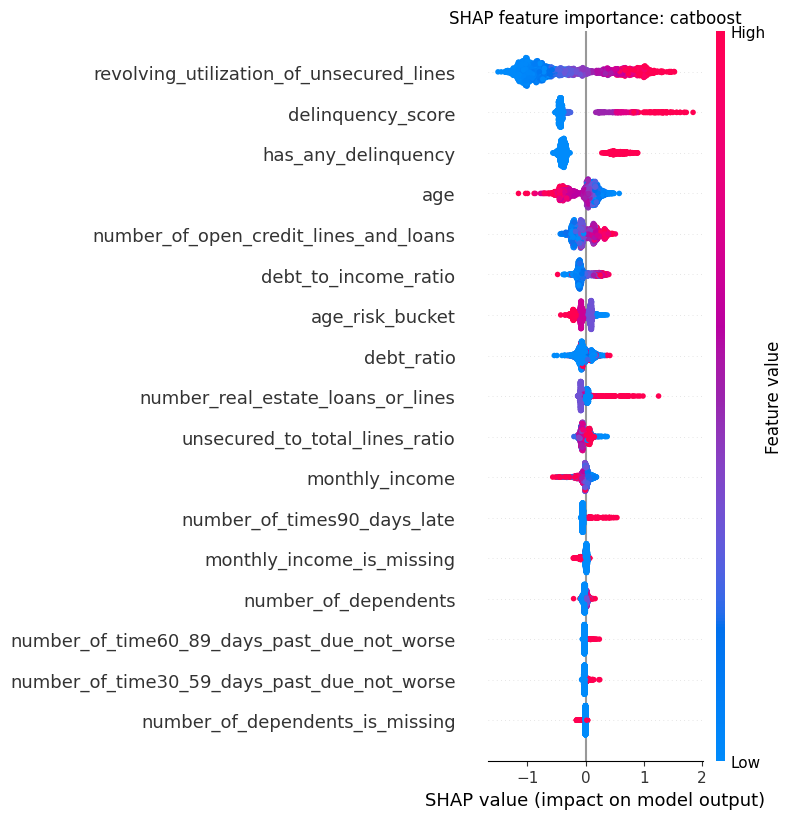

🏃 View run catboost at: http://mlflow:5000/#/experiments/1/runs/6efb3fd5a90148e59d643f2ab44ab29a
🧪 View experiment at: http://mlflow:5000/#/experiments/1
SHAP plot logged to MLflow.


In [17]:
print(f"Computing SHAP values for: {champion_name}")

champion_model = champion["model"]

if champion_name == "logistic_regression":
    explainer = shap.LinearExplainer(champion_model, X_train_proc)
else:
    explainer = shap.TreeExplainer(champion_model)

shap_values = explainer.shap_values(X_val_proc[:2000])


if isinstance(shap_values, list):
    shap_values = shap_values[1]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_val_proc[:2000],
    feature_names=ALL_FEATURES,
    show=False,
)

plt.title(f"SHAP feature importance: {champion_name}")
plt.tight_layout()
plt.savefig("/tmp/shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=champion["run_id"]):
    mlflow.log_artifact("/tmp/shap_summary.png", artifact_path="explainability")

print("SHAP plot logged to MLflow.")

## Optuna tuning (CatBoost, LightGBM, XGBoost)

- Focus on regularization parameters since all three were overfitting.

In [ ]:
N_TRIALS = 50
tuning_results = {}


def objective_catboost(trial: Trial) -> float:
    params: Dict[str, Any] = {
        "iterations": trial.suggest_int("iterations", 200, 600),
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "border_count": trial.suggest_int("border_count", 32, 128),
        "scale_pos_weight": SPW,
        "random_seed": RANDOM_STATE,
        "verbose": 0,
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train_proc, y_train)
    y_prob = model.predict_proba(X_val_proc)[:, 1]
    return roc_auc_score(y_val, y_prob)


def objective_lightgbm(trial: Trial) -> float:
    params: Dict[str, Any] = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight": SPW,
        "random_state": RANDOM_STATE,
        "verbosity": -1,
    }
    model = LGBMClassifier(**params)
    model.fit(
        X_train_proc,
        y_train,
        eval_set=[(X_val_proc, y_val)],
        callbacks=[
            # kill trials that aren't improving speeds up search significantly
            optuna.integration.lightgbm.early_stopping(50, verbose=False),
        ],
    )
    y_prob = model.predict_proba(X_val_proc)[:, 1]
    return roc_auc_score(y_val, y_prob)


def objective_xgboost(trial: Trial) -> float:
    params: Dict[str, Any] = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": SPW,
        "eval_metric": "auc",
        "early_stopping_rounds": 30,
        "random_state": RANDOM_STATE,
        "verbosity": 0,
    }
    model = XGBClassifier(**params)
    model.fit(
        X_train_proc,
        y_train,
        eval_set=[(X_val_proc, y_val)],
        verbose=False,
    )
    y_prob = model.predict_proba(X_val_proc)[:, 1]
    return roc_auc_score(y_val, y_prob)


OBJECTIVES = {
    "catboost": objective_catboost,
    "lightgbm": objective_lightgbm,
    "xgboost": objective_xgboost,
}

for model_name, objective in OBJECTIVES.items():
    print(f"\n{'='*55}")
    print(f"Tuning: {model_name}  ({N_TRIALS} trials)")
    print(f"{'='*55}")

    baseline_auc = results[model_name]["val_auc"]
    parent_run_id = results[model_name]["run_id"]

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name=f"credit_risk_{model_name}",
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    best_auc = study.best_value
    improvement = best_auc - baseline_auc

    print(f"\n  Baseline val AUC : {baseline_auc:.4f}")
    print(f"  Tuned val AUC    : {best_auc:.4f}")
    print(f"  Improvement      : {improvement:+.4f}")
    print(f"  Best params      : {best_params}")

    if model_name == "catboost":
        final_model = CatBoostClassifier(**best_params, verbose=0)
        final_model.fit(X_train_proc, y_train)
    elif model_name == "lightgbm":
        final_model = LGBMClassifier(**best_params, verbosity=-1)
        final_model.fit(X_train_proc, y_train)
    elif model_name == "xgboost":
        final_model = XGBClassifier(**best_params, verbosity=0)
        final_model.fit(
            X_train_proc,
            y_train,
            eval_set=[(X_val_proc, y_val)],
            verbose=False,
        )

    with mlflow.start_run(run_name=f"{model_name}_tuned", nested=True) as tuned_run:
        mlflow.log_param("model_name", f"{model_name}_tuned")
        mlflow.log_param("n_trials", N_TRIALS)
        mlflow.log_param("baseline_auc", round(baseline_auc, 4))
        mlflow.log_params(best_params)

        train_m = evaluate(final_model, X_train_proc, y_train, "train")
        val_m = evaluate(final_model, X_val_proc, y_val, "val")
        mlflow.log_metric("improvement_vs_baseline", round(improvement, 4))
        mlflow.sklearn.log_model(final_model, artifact_path="model")

        tuned_run_id = tuned_run.info.run_id

    tuning_results[model_name] = {
        "run_id": tuned_run_id,
        "val_auc": val_m["val_auc_roc"],
        "val_ks": val_m["val_ks"],
        "val_gini": val_m["val_gini"],
        "best_params": best_params,
        "model": final_model,
        "study": study,
    }


Tuning: catboost  (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]